In [1]:
import sys
import subprocess

subprocess.run([sys.executable, "-m", "pip", "install", "-q", "pytest", "pandas", "matplotlib", "triton"], check=True)
print("Dependencies are ready")

Dependencies are ready


## Проверка CUDA


In [2]:
import subprocess
import torch
import triton

try:
    print(subprocess.check_output(["nvidia-smi"], text=True))
except Exception as exc:
    print("nvidia-smi is not available:", exc)

print("torch:", torch.__version__)
print("torch CUDA build:", torch.version.cuda)
print("triton:", triton.__version__)
assert torch.cuda.is_available(), "CUDA is not available. In Colab choose Runtime -> Change runtime type -> GPU, then rerun."

device = torch.device("cuda")
torch.backends.cuda.matmul.allow_tf32 = True
print("Selected device:", torch.cuda.get_device_name(0))
print("MPS ignored; this notebook uses CUDA only.")


Fri Jun 26 15:48:41 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [9]:
!python -m pytest tests/test_flash_attention.py -q


......                                                                   [100%]
6 passed in 4.67s


## Benchmark

In [10]:
import pandas as pd

from src.backend.flash_attention import benchmark_flash_attention

configs = [
    {"batch_size": 2, "n_heads": 4, "seq_len": 256, "head_dim": 64, "block_m": 16, "block_n": 64, "repeats": 20},
    {"batch_size": 2, "n_heads": 4, "seq_len": 512, "head_dim": 64, "block_m": 16, "block_n": 64, "repeats": 10},
    {"batch_size": 2, "n_heads": 4, "seq_len": 1024, "head_dim": 64, "block_m": 16, "block_n": 64, "repeats": 5},
]

rows = []
for cfg in configs:
    torch.cuda.empty_cache()
    blocked = benchmark_flash_attention(device="cuda", backend="torch-blocked", **cfg)
    torch.cuda.empty_cache()
    triton_result = benchmark_flash_attention(device="cuda", backend="triton", **cfg)
    rows.append(
        dict(
            **cfg,
            torch_ms=blocked.torch_ms,
            blocked_ms=blocked.flash_ms,
            triton_ms=triton_result.flash_ms,
            blocked_speedup=blocked.speedup,
            triton_speedup=triton_result.speedup,
            torch_score_memory_mb=blocked.torch_score_memory_mb,
            flash_score_memory_mb=blocked.flash_score_memory_mb,
            score_memory_reduction=blocked.memory_ratio,
        )
    )

df = pd.DataFrame(rows)
display(df.style.format({
    "torch_ms": "{:.3f}",
    "blocked_ms": "{:.3f}",
    "triton_ms": "{:.3f}",
    "blocked_speedup": "{:.2f}x",
    "triton_speedup": "{:.2f}x",
    "torch_score_memory_mb": "{:.2f}",
    "flash_score_memory_mb": "{:.2f}",
    "score_memory_reduction": "{:.2f}x",
}))


,batch_size,n_heads,seq_len,head_dim,block_m,block_n,repeats,torch_ms,blocked_ms,triton_ms,blocked_speedup,triton_speedup,torch_score_memory_mb,flash_score_memory_mb,score_memory_reduction
0,2,4,256,64,16,64,20,0.521,50.834,0.492,0.01x,0.86x,1.00,0.02,64.00x
1,2,4,512,64,16,64,10,0.620,124.523,1.538,0.00x,0.44x,4.00,0.02,256.00x
2,2,4,1024,64,16,64,5,1.898,480.650,5.467,0.00x,0.35x,16.00,0.02,1024.00x


## Графики


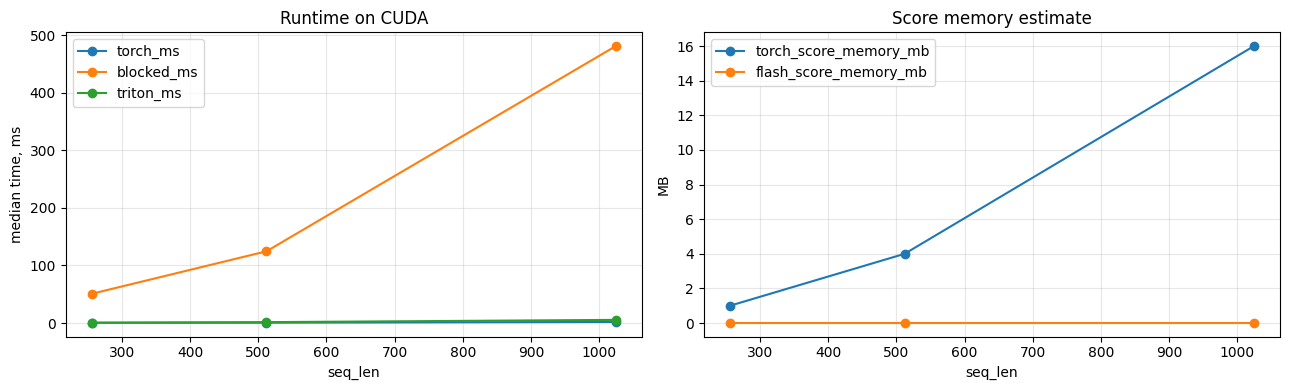

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df.plot(x="seq_len", y=["torch_ms", "blocked_ms", "triton_ms"], marker="o", ax=axes[0])
axes[0].set_title("Runtime on CUDA")
axes[0].set_xlabel("seq_len")
axes[0].set_ylabel("median time, ms")
axes[0].grid(True, alpha=0.3)

df.plot(x="seq_len", y=["torch_score_memory_mb", "flash_score_memory_mb"], marker="o", ax=axes[1])
axes[1].set_title("Score memory estimate")
axes[1].set_xlabel("seq_len")
axes[1].set_ylabel("MB")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
